In [1]:
from google.colab import drive
from pathlib import Path
drive.mount('/content/drive')

#test and make sure the drive is properly mounted
!ls "/content/drive/Shareddrives/EMG POSE deep learning/Erdos_dl_emg_pose/" # this should list all files in the shared drive

Mounted at /content/drive
checkpoints   emg2pose	     model.py		scaler		     welford.py
CNN_model.py  EMG_input.png  __pycache__	training_curves.png
data	      load_data.py   requirements.gdoc	train.py


In [2]:
import os

# Clone the repo (skip if already cloned or running locally)
REPO_DIR = "/content/drive/Shareddrives/EMG POSE deep learning/Erdos_dl_emg_pose/"

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

import torch
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np

# Import from the repo's .py files
from load_data import get_dataloaders, BATCH_SIZE, load_splits, build_dataloaders
from model import EMGPoseLSTM, SequentialEMGPoseLSTM
from CNN_model import CNNPoseLSTM, CNNOnly

from train import (
    train_one_epoch, evaluate,
    save_history, save_model, plot_losses,
)

from data.session import (
	Emg2PoseSessionData, WindowedEmgDataset,
	load_user_scalers, DEFAULT_SCALER_PATH,
)

from welford import apply_welford_to_loaders
print("All modules imported successfully.")

Working directory: /content/drive/Shareddrives/EMG POSE deep learning/Erdos_dl_emg_pose
All modules imported successfully.


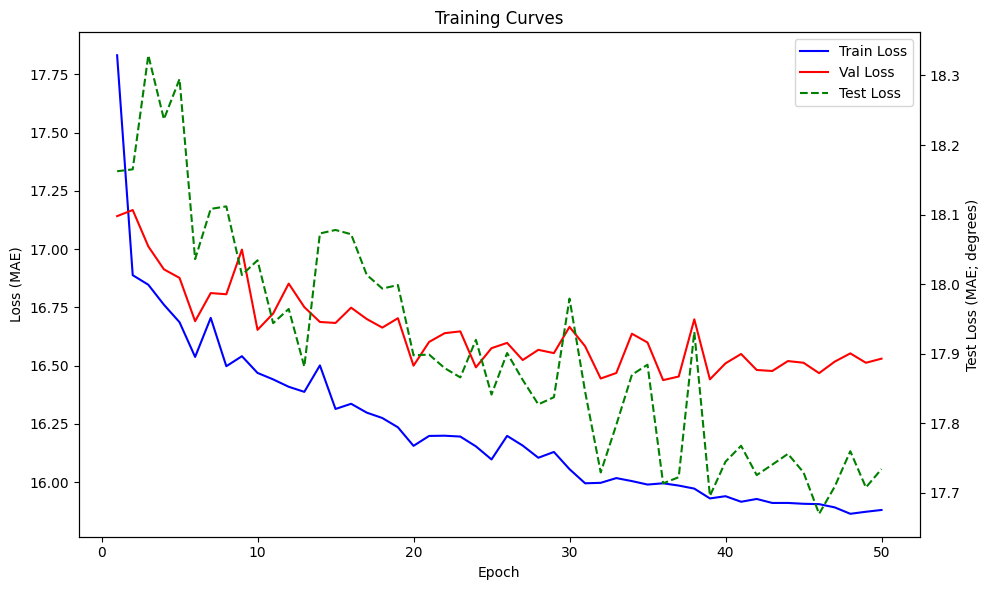

Saved training curves to training_curves.png


In [3]:
def load_history(save_path="checkpoints/loss_history.json"):
    """Save per-epoch loss history to a JSON file.

    Args:
        history: Dict with keys like 'train_loss', 'test_mae', and
                 optionally 'val_loss', each a list of per-epoch values.
        save_path: Where to write the JSON file.
    """
    path = Path(save_path)
    assert path.exists(), 'Could not find the loss history: {}'.format(path)
    with open(path, "r") as f:
        history = json.load(f)

    return history

def plot_losses(history, save_path="training_curves.png"):
    """Plot training curves vs epoch.

    Left y-axis: train and val loss.
    Right y-axis: test loss (if present).

    Args:
        history: Dict with keys 'train_loss', 'val_loss', and
                 optionally 'test_loss', each a list of per-epoch values.
        save_path: Where to save the figure.
    """
    epochs = np.arange(1, len(history["train_loss"]) + 1)

    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Left y-axis: train and val loss
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss (MAE)")
    lines = ax1.plot(epochs, np.rad2deg(history["train_loss"]), "b-", label="Train Loss")
    lines += ax1.plot(epochs, np.rad2deg(history["val_loss"]), "r-", label="Val Loss")
    ax1.tick_params(axis="y")

    # Right y-axis: test loss (if present)
    if "test_loss" in history:
        ax2 = ax1.twinx()
        ax2.set_ylabel("Test Loss (MAE; degrees)")
        lines += ax2.plot(epochs, np.rad2deg(history["test_loss"]), "g--", label="Test Loss")
        ax2.tick_params(axis="y")

    # Combined legend
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, loc="upper right")

    ax1.set_title("Training Curves")
    fig.tight_layout()
    fig.savefig(save_path, dpi=150)
    plt.show()
    print(f"Saved training curves to {save_path}")


output_dir = Path("/content/drive/Shareddrives/EMG POSE deep learning/CNN_LSTM/outputs/cnn_lstm_v2/")
history_saved = Path(os.path.join(output_dir,  "loss_history.json"))
history = load_history(history_saved)

plot_losses(history)

In [4]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Using device: {device}\n")

# # G4 GPU configs
# CONFIG = {
#     # Data
#     "data_dir": "/content/drive/Shareddrives/EMG POSE deep learning/data/data_subset",   # Path to HDF5 files
#     "test_mode": False,                     # True = synthetic data (no download)
#     "use_test": True,                       # True = include test set

#     # Model
#     "hidden_size": 512,
#     "num_layers": 2,

#     # Training
#     "epochs": 10,
#     "lr": 1e-4,
#     "batch_size": 8,
#     "patience": 20,

#     # Output
#     "output_dir": "/content/drive/Shareddrives/EMG POSE deep learning/checkpoints",
# }

# print("Configuration:")
# for k, v in CONFIG.items():
#     print(f"  {k}: {v}")

# model = EMGPoseLSTM(
#     hidden_size=CONFIG["hidden_size"],
#     num_layers=CONFIG["num_layers"],
# ).to(device)

# n_params = sum(p.numel() for p in model.parameters())

# print(f"Model: EMGPoseLSTM ({n_params:,} parameters)")
# print(f"  hidden_size={CONFIG['hidden_size']}, num_layers={CONFIG['num_layers']}")

# best_ckpt = Path(os.path.join(output_dir,  "best_model.pt"))

# if best_ckpt.exists():
#     checkpoint = torch.load(best_ckpt, map_location=device)
#     model.load_state_dict(checkpoint["model_state_dict"])
#     print(f"Loaded best model from epoch {checkpoint['epoch']}")

In [5]:
# Which model to train: "cnn_lstm" or "cnn_only"
MODEL_TYPE = "cnn_lstm"
DATA_DIR = "/content/drive/Shareddrives/EMG POSE deep learning/data/data_subset"
CONFIG = {
    # Data
    "data_dir": DATA_DIR,
    "test_mode": False,
    "use_test": True,
    "meta_dir": os.path.join(REPO_DIR, "meta_subset.csv"),

    # CNN args (shared by both models)
    "filters": 48,         # number of Conv1d output channels
    "kernel_size": 5,      # Conv1d kernel width

    # LSTM args (cnn_lstm only)
    # v2: matched to LSTM-only Welford baseline (LSTM_Dona.ipynb defaults)
    # so the only architectural difference is the CNN front-end
    # v1 used hidden_size=128, num_layers=1 -- saved in outputs/cnn_lstm/
    "hidden_size": 256,
    "num_layers": 2,
    "dropout": 0.1,

    # CNN-only args
    "num_conv_layers": 3,  # stacked Conv1d layers for cnn_only

    # Training
    "epochs": 50,
    "lr": 1e-4,
    "batch_size": 16,
    "patience": 50,

    # Output -- v2 gets its own directory to preserve the v1 run
    "output_dir": os.path.join(REPO_DIR, "outputs", MODEL_TYPE + "_v2"),
}

print("Configuration:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')  # from Sero

model = CNNPoseLSTM(
    hidden_size=CONFIG["hidden_size"],
    num_layers=CONFIG["num_layers"],
    dropout=CONFIG["dropout"],
    filters=CONFIG["filters"],
    kernel_size=CONFIG["kernel_size"],
).to(device)
model_name = "CNN+LSTM"

n_params = sum(p.numel() for p in model.parameters())

print(f"Model: EMGPoseLSTM ({n_params:,} parameters)")
print(f"  hidden_size={CONFIG['hidden_size']}, num_layers={CONFIG['num_layers']}")

best_ckpt = Path(os.path.join(output_dir,  "best_model.pt"))

if best_ckpt.exists():
    checkpoint = torch.load(best_ckpt, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    print(f"Loaded best model from epoch {checkpoint['epoch']}")

Configuration:
  data_dir: /content/drive/Shareddrives/EMG POSE deep learning/data/data_subset
  test_mode: False
  use_test: True
  meta_dir: /content/drive/Shareddrives/EMG POSE deep learning/Erdos_dl_emg_pose/meta_subset.csv
  filters: 48
  kernel_size: 5
  hidden_size: 256
  num_layers: 2
  dropout: 0.1
  num_conv_layers: 3
  epochs: 50
  lr: 0.0001
  batch_size: 16
  patience: 50
  output_dir: /content/drive/Shareddrives/EMG POSE deep learning/Erdos_dl_emg_pose/outputs/cnn_lstm_v2
Model: EMGPoseLSTM (848,804 parameters)
  hidden_size=256, num_layers=2
Loaded best model from epoch 36


In [6]:
def get_small_dataloaders(data_dir=None, metadata=None, test_mode=False,
                    batch_size=BATCH_SIZE, num_workers=0, zscore=True,
                    use_test=False):
	"""Build train/test (and optionally val) dataloaders. Reusable by train.py.

	Args:
		data_dir: Path to directory containing HDF5 session files.
		metadata: Path to emg2pose metadata CSV with train/val/test splits.
		test_mode: If True, use synthetic test data (no download needed).
		batch_size: Batch size for all loaders.
		num_workers: Number of dataloader workers.
		zscore: If True, apply per-user z-score normalization to EMG data
			using scalers from scaler/user_scalers.pkl.
		use_test: If True, include a test DataLoader. Default False
			(only train and test).

	Returns:
		Dict with 'train', 'test' (and optionally 'val') DataLoader instances.
	"""
	# Load per-user scalers for z-score normalization
	user_scalers = None
	if zscore and DEFAULT_SCALER_PATH.exists():
		user_scalers = load_user_scalers()
		print(f"Loaded z-score scalers for {len(user_scalers)} users")

	if test_mode:
		print("=== Running with synthetic test data ===\n")
		test_dir = Path("test_data")
		test_dir.mkdir(exist_ok=True)
		hdf5_path = create_test_hdf5(test_dir)

		paths = [hdf5_path]
		loaders = build_dataloaders(
			train_paths=paths, val_paths=paths, test_paths=paths,
			batch_size=min(batch_size, 4),
			user_scalers=user_scalers,
			use_test=use_test,
		)

	else:
		data_dir = Path(data_dir).expanduser() if data_dir else DEFAULT_DATA_DIR
		assert data_dir.exists(), f"Data directory not found: {data_dir}"

		if metadata:
			metadata = Path(metadata).expanduser()
		else:
			metadata = data_dir / "metadata.csv"
		assert metadata.exists(), f"Metadata CSV not found: {metadata}"

		print(f"=== Loading data from {data_dir} ===")
		print(f"    Metadata: {metadata}\n")

		import pandas as pd
		splits = load_splits(pd.read_csv(metadata))
		available = {p.stem for p in data_dir.glob("*.hdf5")}

		for split_name in splits:
			before = len(splits[split_name])
			splits[split_name] = [f for f in splits[split_name] if f in available]
			after = len(splits[split_name])
			if after < before:
				print(f"  {split_name}: {before} in CSV -> {after} on disk")

		has_empty = any(len(splits[s]) == 0 for s in ["train", "val", "test"])
		if has_empty:
			all_files = sorted(available)
			np.random.seed(42)
			np.random.shuffle(all_files)
			n = len(all_files)
			n_train = max(1, int(0.7 * n))
			n_val = max(1, int(0.15 * n))
			splits = {
				"train": all_files[:n_train],
				"val": all_files[n_train:n_train + n_val],
				"test": all_files[n_train + n_val:],
			}
			print(f"\n  Redistributed {n} files into 70/15/15 splits")

		def resolve_paths(filenames):
			return [data_dir / f"{name}.hdf5" for name in filenames]

		print(f"\nUsing splits: train={len(splits['train'])}, "
			  f"val={len(splits['val'])}, test={len(splits['test'])}")

		n_total = sum(len(v) for v in splits.values())
		effective_batch_size = min(batch_size, 8) if n_total <= 30 else batch_size

		loaders = build_dataloaders(
			train_paths=resolve_paths(splits["train"][:1]),#<- ONLY LOADING A SMALL PORTION OF THE DATASET!!!
			val_paths=resolve_paths(splits["val"][:2]),
			test_paths=resolve_paths(splits["test"][:1]),
			batch_size=effective_batch_size,
			num_workers=num_workers,
			user_scalers=user_scalers,
			use_test=use_test,
		)

	return loaders

# --- Data ---
loaders = get_small_dataloaders(
    data_dir=CONFIG["data_dir"],
    test_mode=CONFIG["test_mode"],
    batch_size=CONFIG["batch_size"],
    use_test=CONFIG["use_test"],
)

apply_welford_to_loaders(loaders)

print(f"\n{'Split':<8} {'Batches':>8} {'Samples':>10}")
for name, loader in loaders.items():
    print(f"{name:<8} {len(loader):>8} {len(loader.dataset):>10}")

# --- Inspect a batch ---
batch = next(iter(loaders["val"]))
print(f"\nBatch shapes:")
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key:<20} {str(val.shape):<25} dtype={val.dtype}")

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.1 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Loaded z-score scalers for 158 users
=== Loading data from /content/drive/Shareddrives/EMG POSE deep learning/data/data_subset ===
    Metadata: /content/drive/Shareddrives/EMG POSE deep learning/data/data_subset/metadata.csv

  test: 6167 in CSV -> 627 on disk
  train: 17136 in CSV -> 953 on disk
  val: 1950 in CSV -> 308 on disk

Using splits: train=953, val=308, test=627
  Z-score scaling: 1/1 sessions matched a user scaler
  Z-score scaling: 0/2 sessions matched a user scaler
  Users without scalers (skipped): ['2251681168']
  Z-score scaling: 0/1 sessions matched a user scaler
  Users without scalers (skipped): ['7e08fa55fd']
Applied Welford normalization to 4 session datasets

Split     Batches    Samples
train           3         60
val             1         13
test            1          8

Batch shapes:
  emg                  torch.Size([13, 16, 10000]) dtype=torch.float32
  joint_angles         torch.Size([13, 20, 10000]) dtype=torch.float32
  no_ik_failure        torch.Size([


Batch shapes:
  emg                  torch.Size([8, 16, 10000]) dtype=torch.float32
  joint_angles         torch.Size([8, 20, 10000]) dtype=torch.float32
  no_ik_failure        torch.Size([8, 10000])    dtype=torch.bool
  window_start_idx     torch.Size([8])           dtype=torch.int64
  window_end_idx       torch.Size([8])           dtype=torch.int64
Batch organizations {Dict}:
dict_keys(['emg', 'joint_angles', 'no_ik_failure', 'window_start_idx', 'window_end_idx'])
Aligned first batch of samples: 
1/8 of the batch


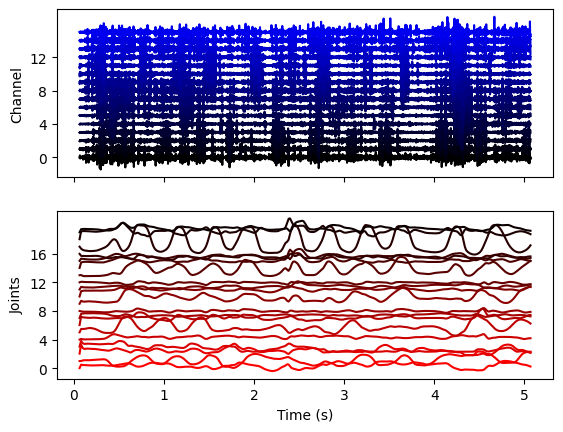

2/8 of the batch


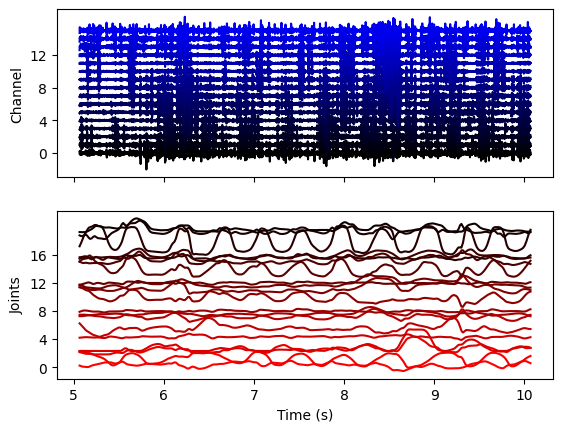

3/8 of the batch


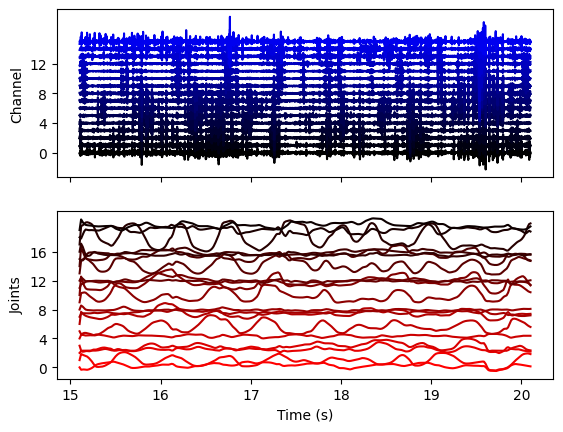

4/8 of the batch


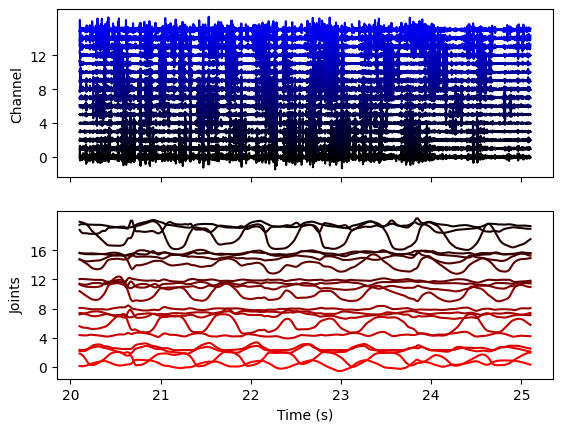

5/8 of the batch


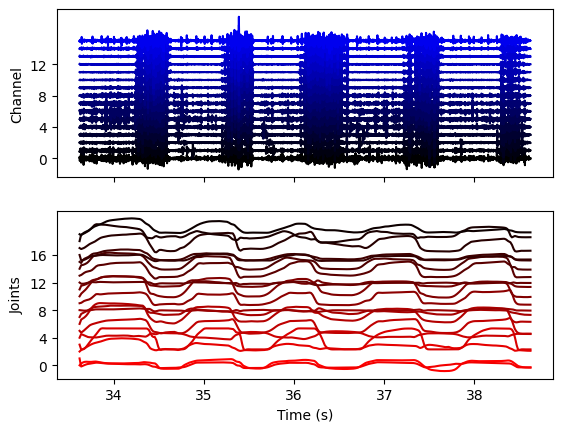

6/8 of the batch


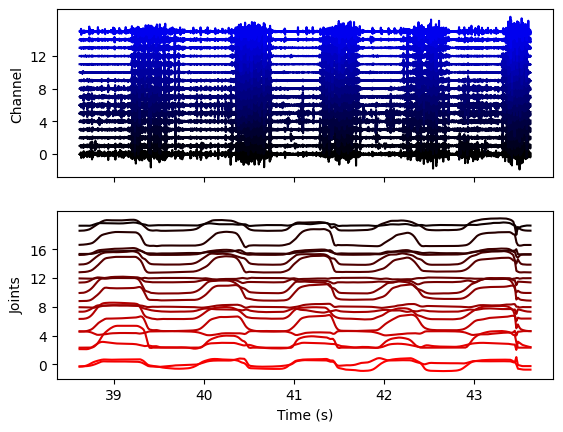

7/8 of the batch


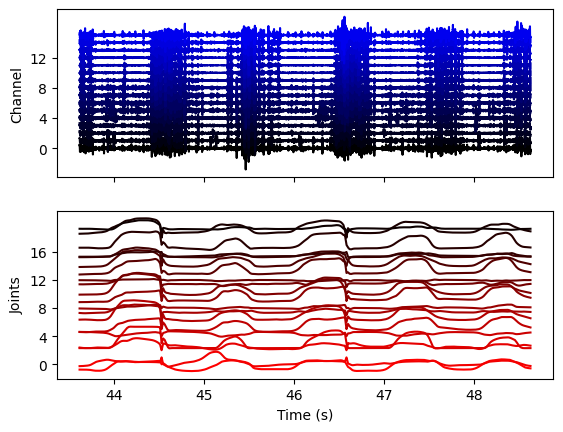

8/8 of the batch


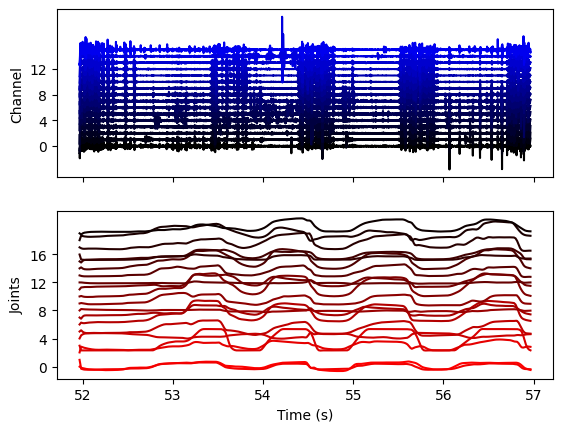

In [7]:

import matplotlib.pyplot as plt
time = np.arange(10000)/2000

# --- Inspect a batch ---
batch = next(iter(loaders["test"]))
print(f"\nBatch shapes:")
for key, val in batch.items():
    if isinstance(val, torch.Tensor):
        print(f"  {key:<20} {str(val.shape):<25} dtype={val.dtype}")

print('Batch organizations {Dict}:')
print(batch.keys())

'''
  batch size  = 8
  window size = 1 sec, 2000 samples

  emg                  torch.Size([8, 16, 2000]) dtype=torch.float32 #muscle activity (16 channels)
  joint_angles         torch.Size([8, 20, 2000]) dtype=torch.float32 #jopint angle movements (20 points)
  no_ik_failure        torch.Size([8, 2000])     dtype=torch.bool  #proper joint angles/no failures
  window_start_idx     torch.Size([8])           dtype=torch.int64 #start index in the large dataset
  window_end_idx       torch.Size([8])           dtype=torch.int64 #end index in the large dataset
'''

print('Aligned first batch of samples: ')

ch_mult = 4
ang_mult = 0.5

channels = np.arange(16)
jointang = np.arange(20)

for b in np.arange(8):
  print('{}/8 of the batch'.format(b+1))
  fig, axs = plt.subplots(2,1)
  start_time = np.array(batch['window_start_idx'][b]/2000)
  for i in np.arange(16): # 16 channels
    axs[0].plot(time+start_time, batch['emg'][b][i] + i*ch_mult, color=(0,0,i/16))
  axs[0].set_yticks(channels[::4]*ch_mult)
  axs[0].set_yticklabels(channels[::4])
  axs[0].set_ylabel('Channel')
  axs[0].set_xticklabels([])

  for i in np.arange(20): # 20 joint angle measures
    axs[1].plot(time+start_time, batch['joint_angles'][b][i] +  i*ang_mult, color=((20-i)/20,0,0))
  axs[1].set_xlabel('Time (s)')
  axs[1].set_yticks(jointang[::4]*ang_mult)
  axs[1].set_yticklabels(jointang[::4])
  axs[1].set_ylabel('Joints')
  plt.show()

In [8]:
model.eval()
with torch.no_grad():
    y_pred = model(batch['emg'])
print(y_pred.shape)

torch.Size([8, 20, 10000])


Aligned first batch of samples: 


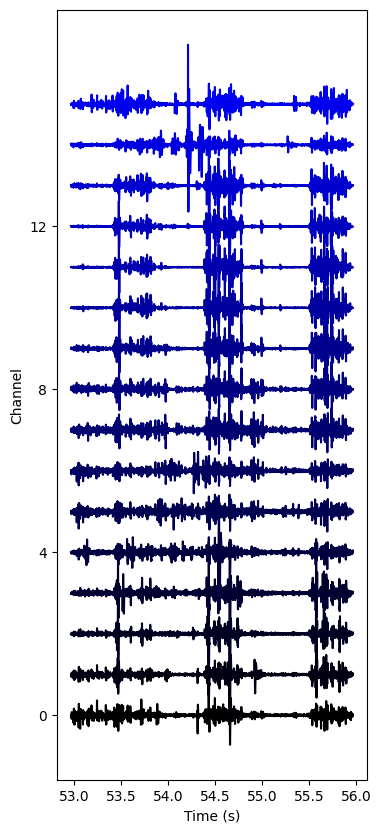

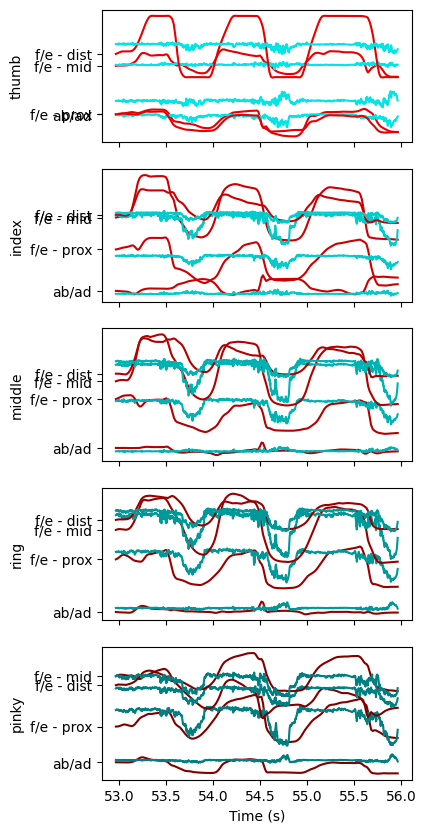

In [12]:
print('Aligned first batch of samples: ')

ch_mult = 10
ang_mult = 0.5

channels = np.arange(16)
jointang = np.arange(20)

fig, axs = plt.subplots(1,1, figsize=(4,10))
b = 7

length_show = 3
offset = 2000

start_time = np.array(batch['window_start_idx'][b]/2000)
for i in np.arange(16): # 16 channels
  axs.plot(time[offset:int(length_show*2000+offset)]+start_time, batch['emg'][b][i][offset:int(length_show*2000+offset)] + i*ch_mult, color=(0,0,i/16))
axs.set_yticks(channels[::4]*ch_mult)
axs.set_yticklabels(channels[::4])
axs.set_ylabel('Channel')
axs.set_xlabel('Time (s)')
# plt.savefig(os.path.join('EMG_input.png', dpi=300)
plt.savefig('EMG_input.png', dpi=300)  # from Sero
plt.show()

fig, axs = plt.subplots(5,1, figsize=(4,10))

joints = ['ab/ad', 'f/e - prox', 'f/e - mid', 'f/e - dist']
fingers = ['thumb', 'index', 'middle', 'ring', 'pinky']

last_finger_index = -1
ja_start = []
for i in np.arange(20): # 20 joint angle measures
    finger_index = int((i//4))
    ja = batch['joint_angles'][b][i][offset:int(length_show*2000+offset)] + i*ang_mult
    if last_finger_index!=(finger_index-1):
      last_finger_index=finger_index-1
      ja_start = [ja[0]]
    else:
      ja_start.append(ja[0])
    axs[finger_index].plot(time[offset:int(length_show*2000+offset)]+start_time, ja,
                           color=((10-finger_index-1)/10,0,0))
    axs[finger_index].plot(time[offset:int(length_show*2000+offset)]+start_time,
                           y_pred[b][i][offset:int(length_show*2000+offset)] + i*ang_mult,
                           color=(0, (10-finger_index-1)/10,(10-finger_index-1)/10))
    axs[finger_index].set_ylabel(fingers[finger_index])
    if (i%4)==3:
      axs[finger_index].set_yticks(ja_start)
      axs[finger_index].set_yticklabels(joints)
    if finger_index < 4:
      axs[finger_index].set_xticklabels([])
axs[4].set_xlabel('Time (s)')
plt.show()

In [10]:
# Clone emg2pose for 3D hand mesh visualization (UmeTrack forward kinematics)
!git clone --depth 1 -q https://github.com/facebookresearch/emg2pose.git /content/emg2pose_repo 2>/dev/null || echo "Already cloned"

# 3D hand mesh — ground truth vs predicted at a single timestep
# This is what the 20 joint angle numbers from the prediction traces
# actually look like as a physical hand pose
#
# Uses UmeTrack forward kinematics to go from joint angles -> 3D mesh
# Same FK pipeline the emg2pose paper uses for their LandmarkDistances metric
#
# Our models output 20 DOF (4 joints x 5 fingers)
# UmeTrack expects 22 (adds 2 wrist angles we don't predict, so we pad with zeros)

import json, types, importlib.util, sys
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Load UmeTrack FK modules directly from file paths
# The pip-installed 'lib' package from a previous cell shadows the real one,
# so we use importlib to load each .py by filepath and wire up the package
# hierarchy manually so relative imports (from .hand import ...) work
umetrack_path = '/content/emg2pose_repo/emg2pose/UmeTrack'

def _load_module(fullname, filepath):
    spec = importlib.util.spec_from_file_location(fullname, filepath)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[fullname] = mod
    spec.loader.exec_module(mod)
    return mod

# Create the package hierarchy so relative imports resolve
sys.modules['lib'] = types.ModuleType('lib')
sys.modules['lib.common'] = types.ModuleType('lib.common')

# Load in dependency order: so3 -> hand -> hand_skinning
_load_module('lib.common.pytorch3d_transforms_so3', f'{umetrack_path}/lib/common/pytorch3d_transforms_so3.py')
hand_mod = _load_module('lib.common.hand', f'{umetrack_path}/lib/common/hand.py')
skinning_mod = _load_module('lib.common.hand_skinning', f'{umetrack_path}/lib/common/hand_skinning.py')

HandModel = hand_mod.HandModel
_skin_points = skinning_mod._skin_points

# Load the generic hand model (bone structure, mesh vertices, skinning weights)
# This JSON defines how joint angles map to 3D vertex positions
with open(f'{umetrack_path}/dataset/generic_hand_model.json', 'rb') as f:
    hm_dict = json.load(f)
hand_model = HandModel(**{
    k: torch.Tensor(v) if isinstance(v, list) else v
    for k, v in hm_dict.items()
})

# Pick the midpoint of the time window shown in the prediction traces above
# So this mesh is a snapshot of what the hand looks like at that exact moment
t_idx = offset + int(length_show * 1000)

# Grab the 20 joint angles at that timestep from ground truth and model prediction
# ja_gt = batch['joint_angles'][b, :, t_idx].numpy()
ja_gt = np.array([ 0.2237,  0.0910,  0.1825,  0.5838, -0.1461,  0.2805,  0.6947,  0.1950,
        -0.1417,  0.5595,  0.9206,  0.4364, -0.1160,  0.5581,  0.9315,  0.3867,
        -0.1680,  0.5447,  0.7194,  0.4030])
# ja_pred = y_pred[b, :, t_idx].detach().numpy()
ja_pred = np.zeros(20)

# Pad from 20 -> 22 by appending two zero wrist angles
ja_gt_22 = np.concatenate([ja_gt, np.zeros(2)])
ja_pred_22 = np.concatenate([ja_pred, np.zeros(2)])

def joint_angles_to_mesh(ja_22, hand_model, color='lightpink', opacity=0.5):
    """
    Takes 22 joint angles and returns a plotly Mesh3d trace of the hand
    Steps: joint angles -> forward kinematics -> skinned vertices -> triangle mesh
    """
    ja_t = torch.from_numpy(ja_22).float()

    # Identity wrist transform (no global rotation/translation)
    wrist_xf = torch.eye(4)

    # _skin_points does the actual FK: rotates each bone by its joint angle,
    # then blends nearby mesh vertices using skinning weights
    vertices = _skin_points(
        hand_model.joint_rest_positions,   # where each joint sits at rest
        hand_model.joint_rotation_axes,    # which axis each joint rotates around
        hand_model.dense_bone_weights,     # how much each bone influences each vertex
        ja_t,                              # the joint angles we want to render
        hand_model.mesh_vertices,          # the mesh vertices at rest pose
        wrist_xf,                          # global wrist position (identity = origin)
    )

    verts = vertices.numpy()
    tris = hand_model.mesh_triangles.numpy()
    x, y, z = verts.T
    i, j, k = tris.T.astype(int)

    return go.Mesh3d(
        x=x, y=y, z=z, i=i, j=j, k=k,
        color=color, opacity=opacity,
        lighting=dict(ambient=0.85, diffuse=0.2, specular=0.5, roughness=1.0),
        lightposition=dict(x=10, y=-500, z=-1),
    )

# Activity at this timestep (mean absolute joint angle in degrees)
t_idx_activity = torch.rad2deg(torch.abs(batch['joint_angles'][b, :, t_idx])).mean().item()

# Side-by-side comparison
fig = make_subplots(
    rows=1, cols=2,
    specs=[[{'type': 'scene'}, {'type': 'scene'}]],
    subplot_titles=[
        f'mean joint angle', '0 joint anlge'],
)

gt_mesh = joint_angles_to_mesh(ja_gt_22, hand_model, color='blue', opacity=1.0)
pred_mesh = joint_angles_to_mesh(ja_pred_22, hand_model, color='cyan', opacity=1.0)

fig.add_trace(gt_mesh, row=1, col=1)
fig.add_trace(pred_mesh, row=1, col=2)

# Same camera angle on both so differences are easy to spot
# Larger eye values = more zoomed out
camera = dict(eye=dict(x=-0.45, y=-1.6, z=0.55), projection=dict(type='perspective'))
scene_layout = dict(
    xaxis=dict(showbackground=False, showticklabels=False, showgrid=False, title=''),
    yaxis=dict(showbackground=False, showticklabels=False, showgrid=False, title=''),
    zaxis=dict(showbackground=False, showticklabels=False, showgrid=False, title=''),
    camera=camera,
    aspectmode='data',
)
fig.update_layout(
    scene=scene_layout,
    scene2=scene_layout,
    height=400, width=800,
    showlegend=False,
)
fig.show()